In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from greenPower import carbon_intensity 
from HPCSimPickJobs import *


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
EXPERIMENT_PATH = "lublin_256_carbon_all1/MARL_carbon_min_only"  # e.g., 
WORKLOAD = "./data/lublin_256_frontloaded.swf"

In [4]:

def initialize_environment(workload, backfill, debug, seed):
    # Resolve workload path
    if workload.endswith('.swf'):
        workload_file = workload
    else:
        workload_file = f"./data/{workload}.swf"
    print("Using workload:", workload_file)

    # Initialize environment
    env = HPCEnv(backfill=backfill, debug=debug)
    env.my_init(workload_file)
    env.seed(seed)

    # Override job count for the episode
    env.reset()
    # Prepare episode with exactly JOBS_PER_EPISODE jobs

    return env

In [5]:
env = initialize_environment(WORKLOAD, False, False, 0)
env.episode_start_hour_offset

Using workload: ./data/lublin_256_frontloaded.swf
Initialize Simple HPC Env
loading workloads from dataset: ./data/lublin_256_frontloaded.swf
Using constant power: 500.0 watts per processor
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 124707


7451

In [6]:
hours = len(env.cluster.carbonIntensity.carbonIntensityList)
assert(hours / 24 == 365)
print("✅ Carbon intensity list has the correct length (8670 hours, equal to 365 days)")

✅ Carbon intensity list has the correct length (8670 hours, equal to 365 days)


Start offset (hour) 7451
Seconds after sim:  0
{'lastTime': 3600, 'carbonIntensity': 74.42}
Seconds after sim:  3600
{'lastTime': 3600, 'carbonIntensity': 76.04}
Seconds after sim:  7200
{'lastTime': 3600, 'carbonIntensity': 84.29}
Seconds after sim:  10800
{'lastTime': 3600, 'carbonIntensity': 97.64}
Seconds after sim:  14400
{'lastTime': 3600, 'carbonIntensity': 116.01}
Seconds after sim:  18000
{'lastTime': 3600, 'carbonIntensity': 107.6}
Seconds after sim:  21600
{'lastTime': 3600, 'carbonIntensity': 95.96}
Seconds after sim:  25200
{'lastTime': 3600, 'carbonIntensity': 86.06}
Seconds after sim:  28800
{'lastTime': 3600, 'carbonIntensity': 86.02}
Seconds after sim:  32400
{'lastTime': 3600, 'carbonIntensity': 115.13}
Seconds after sim:  36000
{'lastTime': 3600, 'carbonIntensity': 107.71}
Seconds after sim:  39600
{'lastTime': 3600, 'carbonIntensity': 80.4}
Seconds after sim:  43200
{'lastTime': 3600, 'carbonIntensity': 71.53}
Seconds after sim:  46800
{'lastTime': 3600, 'carbonInte

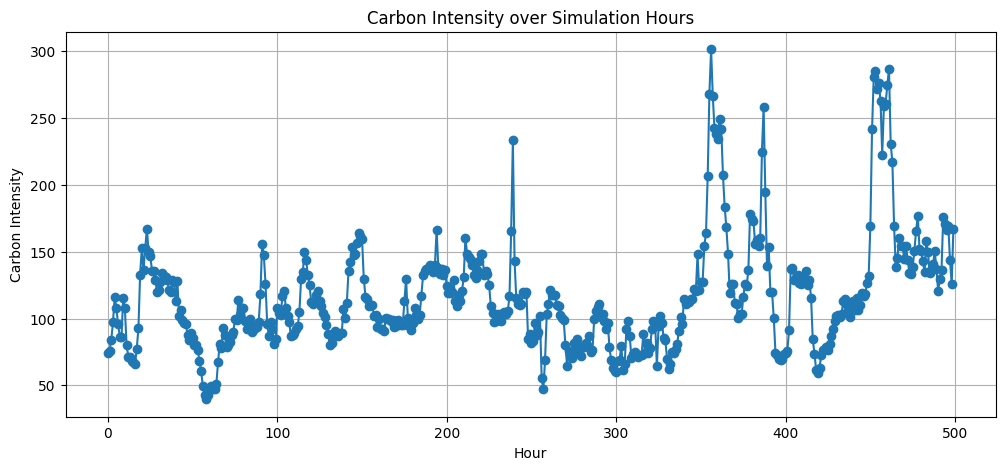

In [15]:
sim_length_hours = 500
def test_carbon_intensity_slots(carbon_intensity, sim_length_hours):
    # Currenttime is a seconds after start of the simulation. Lets a simulation is 100 hours.

    tt = np.arange(0,sim_length_hours*3600,3600)
    carbon_vals = []
    for t in tt:
        print("Seconds after sim: ", t)
        slots = carbon_intensity.getCarbonIntensitySlot(currentTime=t)
        print(slots[0])
        carbon_vals.append(slots[0])
    return carbon_vals
print("Start offset (hour)", env.cluster.carbonIntensity.start_offset)
carbon_vals = test_carbon_intensity_slots(env.cluster.carbonIntensity, sim_length_hours=sim_length_hours)

assert(len(carbon_vals) == sim_length_hours)

carbon_intensity_values = [v['carbonIntensity'] for v in carbon_vals]
plt.figure(figsize=(12, 5))
plt.plot(range(sim_length_hours), carbon_intensity_values, marker='o')
plt.xlabel('Hour')
plt.ylabel('Carbon Intensity')
plt.title('Carbon Intensity over Simulation Hours')
plt.grid(True)
plt.show()
